In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv("mumbai-house-price-data-cleaned.csv")
df.head(10)
target_Col='price'

#  The dataset consists of about 70,000+ entries across 15 columns. Below is a breakdown of the columns:

-  title: (object) Title or headline of the property listing.
-  price: (int64) The total price of the property in Indian Rupees.
-  area: (int64) The built-up area of the property in square feet.
-  price_per_sqft: (float64) Price per square foot in Indian Rupees, calculated from the total price and area.
-  locality: (object) The locality or neighborhood where the property is located.
-  city: (object) The city of the property, which is predominantly Mumbai.
-  property_type: (object) Type of property (e.g., apartment, villa).
-  bedroom_num: (int64) Number of bedrooms in the property.
-  bathroom_num: (int64) Number of bathrooms in the property.
-  balcony_num: (int64) Number of balconies in the property.
-  furnished: (object) Indicates whether the property is furnished, semi-furnished, or unfurnished.
-  age: (int64) Age of the property in years.
-  total_floors: (int64) The total number of floors of the house.
-  latitude: (float64) Latitude coordinates of the property for geospatial analysis.
-  longitude: (float64) Longitude coordinates of the property for geospatial analysis.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71938 entries, 0 to 71937
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           71938 non-null  object 
 1   price           71938 non-null  int64  
 2   area            71938 non-null  int64  
 3   price_per_sqft  71938 non-null  float64
 4   locality        71938 non-null  object 
 5   city            71938 non-null  object 
 6   property_type   71938 non-null  object 
 7   bedroom_num     71938 non-null  int64  
 8   bathroom_num    71938 non-null  int64  
 9   balcony_num     71938 non-null  int64  
 10  furnished       71938 non-null  object 
 11  age             71938 non-null  int64  
 12  total_floors    71938 non-null  int64  
 13  latitude        71938 non-null  float64
 14  longitude       71938 non-null  float64
dtypes: float64(3), int64(7), object(5)
memory usage: 8.2+ MB


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", target_Col)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: price
Numerical columns: ['price', 'area', 'price_per_sqft', 'bedroom_num', 'bathroom_num', 'balcony_num', 'age', 'total_floors', 'latitude', 'longitude']
Categorical columns: ['title', 'locality', 'city', 'property_type', 'furnished']


In [ ]:
df.isnull().sum()

,0
title,0
price,0
area,0
price_per_sqft,0
locality,0
city,0
property_type,0
bedroom_num,0
bathroom_num,0
balcony_num,0


In [ ]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

title
                                     11595
Paradise Sai World Empire Phase 1      384
Runwal Bliss                           371
Piramal Vaikunth Thane                 348
Hiranandani Fortune City               280
Paradise Sai World City                246
JP North                               237
Kalpataru Parkcity                     200
Swaminarayan City                      188
Lodha Sterling                         177
Hiranandani Meadows                    170
Lodha Casa Selva A to C                163
Gurukrupa Marina Enclave               162
Godrej Ascend                          161
Piramal Aranya                         159
Piramal Revanta                        156
Dosti West County                      147
Omkar Alta Monte                       144
Paradigm Opulence Stardom              139
Arihant Clan Aalishan Phase 1          135
Name: count, dtype: int64
price
20000000    790
15000000    720
11000000    687
12500000    658
10000000    641
8500000     619
950000

# no missing values are present in the dataset

In [ ]:
# This removes rows only if EVERY single column is exactly the same
df_cleaned = df.drop_duplicates(keep='first')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")

Original shape: (71938, 15)
Cleaned shape: (51767, 15)


In [ ]:
print(f"Number of duplicates: {df_cleaned.duplicated().sum()}")

Number of duplicates: 0


In [ ]:
df_cleaned.head(30)

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,Octave Parijas Horizon,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,Shakti Siyara Heights,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,Bhagwati Bhagwati Celeste,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,J P Ruchita Bliss,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319
5,Saras Destiny,4900320,720,6806.000000,Ulwe,Mumbai,Apartment,1,1,0,Unfurnished,0,1,18.967562,73.024956
6,Nexus Ratan Heritage,14000000,652,21472.392638,Jogeshwari,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.137762,72.860130
7,Aristocrat Guruprasad Divine Residency,16400255,565,29027.000000,Chembur,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.032211,72.895226
8,9 PBR 9 PBR,74998440,1770,42372.000000,Nerul,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.008259,73.013031
9,Prestige Bellanza Phase 2 Wing D E F At The Pr...,65900000,2600,25346.153846,Mulund,Mumbai,Apartment,4,5,0,Unfurnished,0,1,19.184473,72.940758


In [ ]:
# Convert empty strings and whitespace to NaN
df_cleaned['title'] = df_cleaned['title'].replace(r'^\s*$', np.nan, regex=True)

# checking the null values again
print(df_cleaned['title'].isnull().sum())

9591


/tmp/ipykernel_5262/1775004280.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['title'] = df_cleaned['title'].replace(r'^\s*$', np.nan, regex=True)


In [ ]:
df_cleaned['title'] = df_cleaned['title'].fillna("Unknown Project")

/tmp/ipykernel_5262/949905818.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['title'] = df_cleaned['title'].fillna("Unknown Project")


###  I noticed the 'title' column had hidden missing values—empty strings that weren't showing up as nulls. I converted these to NaNs and filled them for the EDA to maintain data volume, but removed the column for the predictive model to prevent overfitting on specific building names.

In [ ]:
df_cleaned[num_cols].describe(percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9])

,price,area,price_per_sqft,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude
count,5.176700e+04,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000,51767.000000
mean,2.029837e+07,973.682018,18390.293804,2.000444,2.100836,0.164468,2.363919,1.003748,19.172944,72.966697
std,3.467431e+07,661.831575,13099.807453,0.929445,0.862753,0.592744,4.377339,0.323734,0.532951,0.457737
min,3.200000e+04,123.000000,25.376685,0.000000,1.000000,0.000000,0.000000,1.000000,12.889899,72.435379
10%,3.900000e+06,461.000000,5821.623792,1.000000,1.000000,0.000000,0.000000,1.000000,19.010637,72.831490
20%,5.626496e+06,573.000000,8000.000000,1.000000,1.000000,0.000000,0.000000,1.000000,19.053326,72.847275
30%,7.500000e+06,646.000000,9833.333333,1.000000,2.000000,0.000000,0.000000,1.000000,19.082502,72.864532
40%,9.500000e+06,706.000000,12500.000000,2.000000,2.000000,0.000000,0.000000,1.000000,19.123003,72.878838
50%,1.200000e+07,804.000000,15642.000000,2.000000,2.000000,0.000000,0.000000,1.000000,19.160484,72.913185
60%,1.520000e+07,950.000000,18750.000000,2.000000,2.000000,0.000000,0.000000,1.000000,19.196133,72.962099


In [ ]:
df_cleaned[num_cols].describe(percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]).T

,count,mean,std,min,10%,20%,30%,40%,50%,60%,70%,80%,90%,max
price,51767.0,2.029837e+07,3.467431e+07,32000.000000,3.900000e+06,5.626496e+06,7.500000e+06,9.500000e+06,1.200000e+07,1.520000e+07,1.930000e+07,2.550000e+07,4.000000e+07,2.147484e+09
area,51767.0,9.736820e+02,6.618316e+02,123.000000,4.610000e+02,5.730000e+02,6.460000e+02,7.060000e+02,8.040000e+02,9.500000e+02,1.060000e+03,1.240000e+03,1.600000e+03,2.410900e+04
price_per_sqft,51767.0,1.839029e+04,1.309981e+04,25.376685,5.821624e+03,8.000000e+03,9.833333e+03,1.250000e+04,1.564200e+04,1.875000e+04,2.200000e+04,2.615732e+04,3.410600e+04,2.900000e+05
bedroom_num,51767.0,2.000444e+00,9.294450e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,1.500000e+01
bathroom_num,51767.0,2.100836e+00,8.627529e-01,1.000000,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,3.000000e+00,1.500000e+01
balcony_num,51767.0,1.644677e-01,5.927436e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.500000e+01
age,51767.0,2.363919e+00,4.377339e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,4.000000e+00,8.000000e+00,5.700000e+01
total_floors,51767.0,1.003748e+00,3.237341e-01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+01
latitude,51767.0,1.917294e+01,5.329514e-01,12.889899,1.901064e+01,1.905333e+01,1.908250e+01,1.912300e+01,1.916048e+01,1.919613e+01,1.921897e+01,1.924502e+01,1.928367e+01,7.286834e+01
longitude,51767.0,7.296670e+01,4.577374e-01,72.435379,7.283149e+01,7.284727e+01,7.286453e+01,7.287884e+01,7.291319e+01,7.296210e+01,7.299583e+01,7.307370e+01,7.311754e+01,9.180441e+01


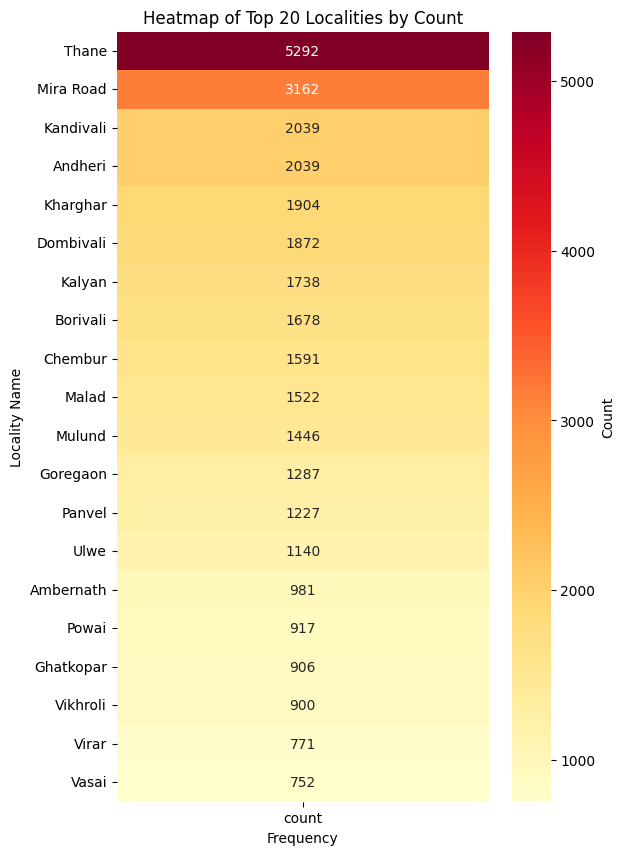

In [ ]:
locality_counts = df_cleaned['locality'].value_counts().head(20).to_frame()

# 2. Plotting
plt.figure(figsize=(6, 10))
sns.heatmap(locality_counts, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Count'})

plt.title("Heatmap of Top 20 Localities by Count")
plt.ylabel("Locality Name")
plt.xlabel("Frequency")
plt.show()

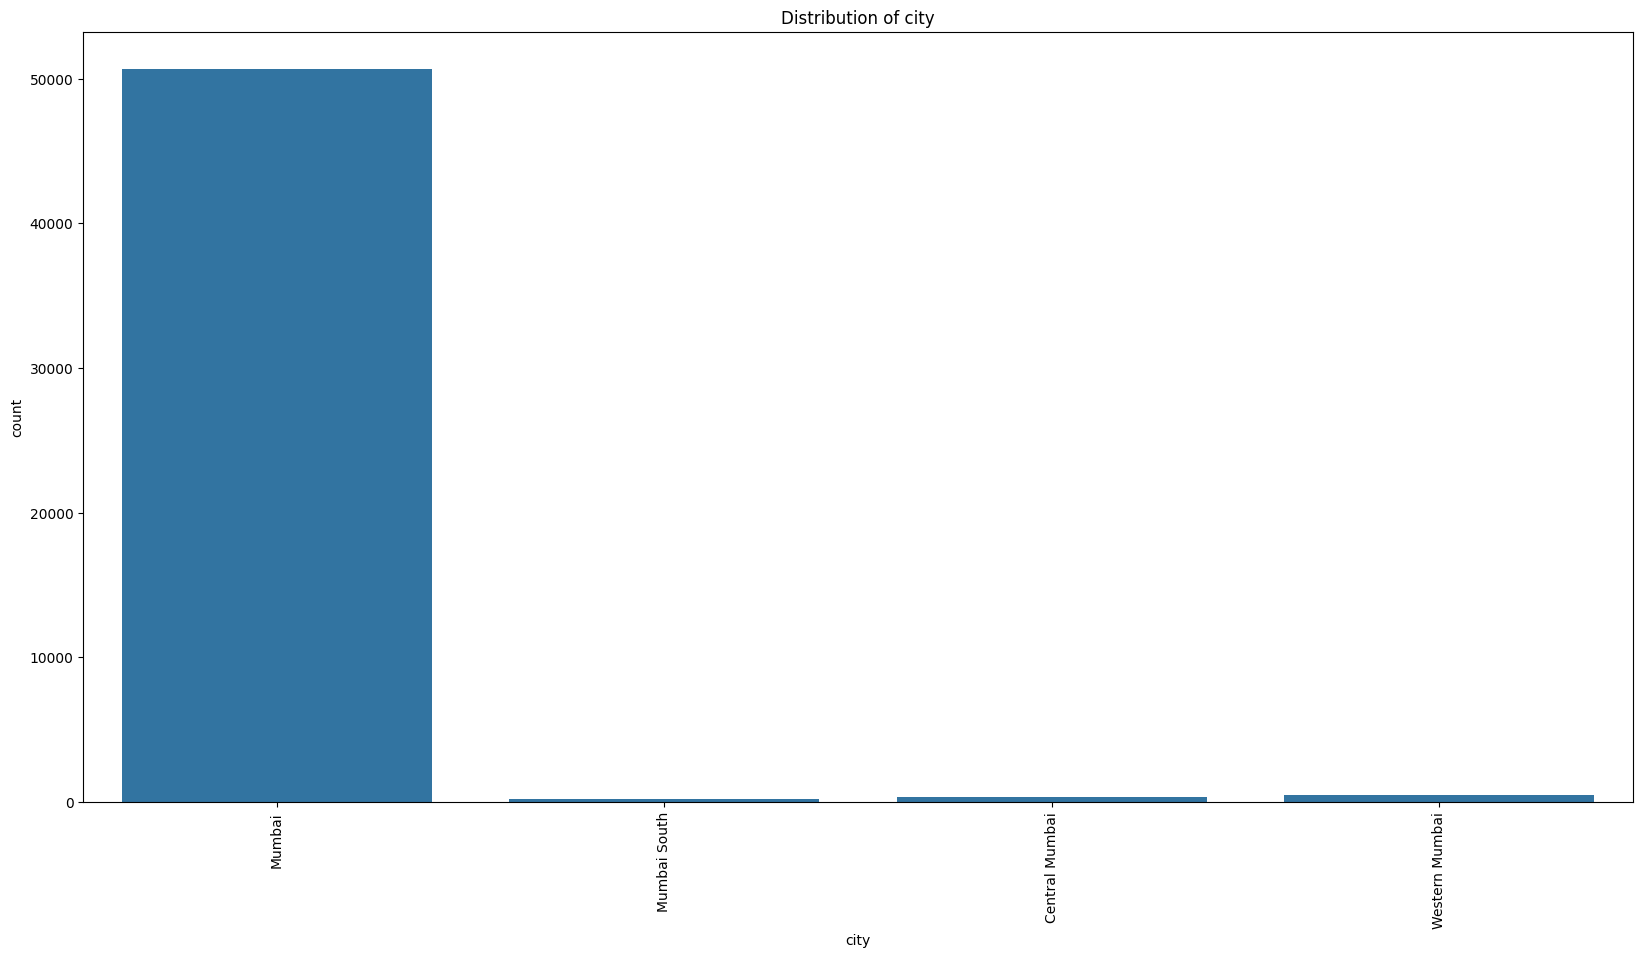

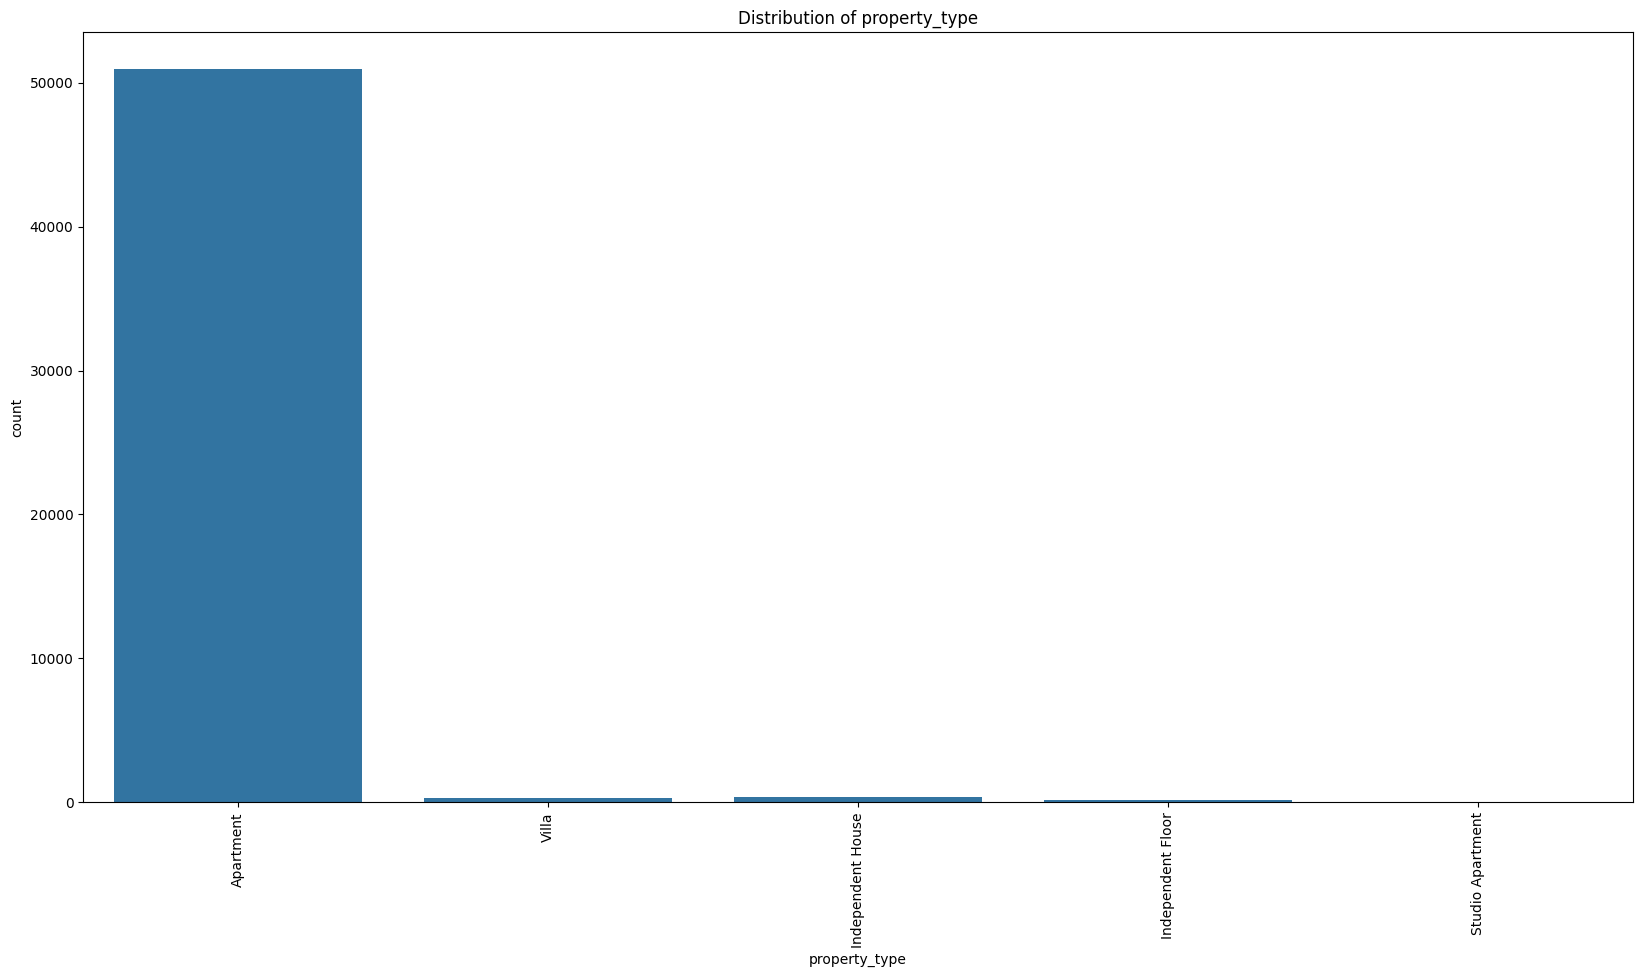

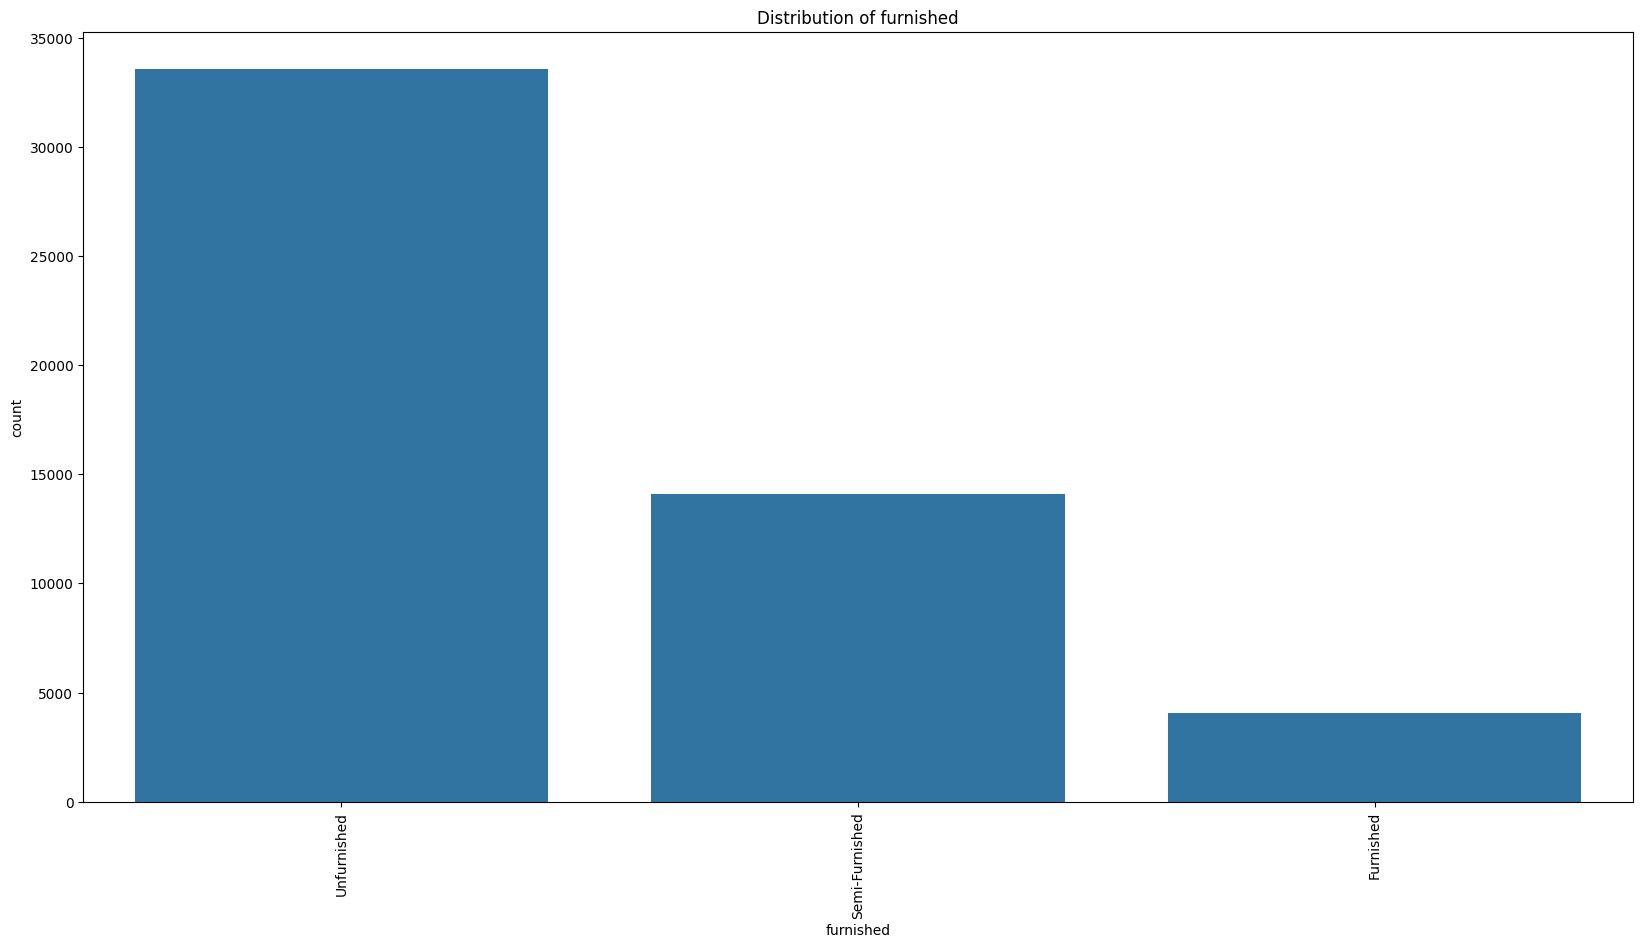

In [ ]:
categorical_col=['city', 'property_type', 'furnished']
for col in categorical_col:
    plt.figure(figsize=(20, 10))
    sns.countplot(x=col, data=df_cleaned)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
for col in cat_cols:
    print(df_cleaned[col].value_counts().head(10))

title
Unknown Project             9591
Runwal Bliss                 139
Hiranandani Fortune City     123
Piramal Vaikunth Thane       123
Radius Ten BKC               111
Gurukrupa Marina Enclave     107
Lodha Casa Selva A to C      100
Hiranandani Meadows           98
Dosti Eastern Bay             98
Omkar Alta Monte              98
Name: count, dtype: int64
locality
Thane        5292
Mira Road    3162
Kandivali    2039
Andheri      2039
Kharghar     1904
Dombivali    1872
Kalyan       1738
Borivali     1678
Chembur      1591
Malad        1522
Name: count, dtype: int64
city
Mumbai            50711
Western Mumbai      489
Central Mumbai      362
Mumbai South        205
Name: count, dtype: int64
property_type
Apartment            50960
Independent House      347
Villa                  323
Independent Floor      135
Studio Apartment         2
Name: count, dtype: int64
furnished
Unfurnished       33581
Semi-Furnished    14117
Furnished          4069
Name: count, dtype: int64


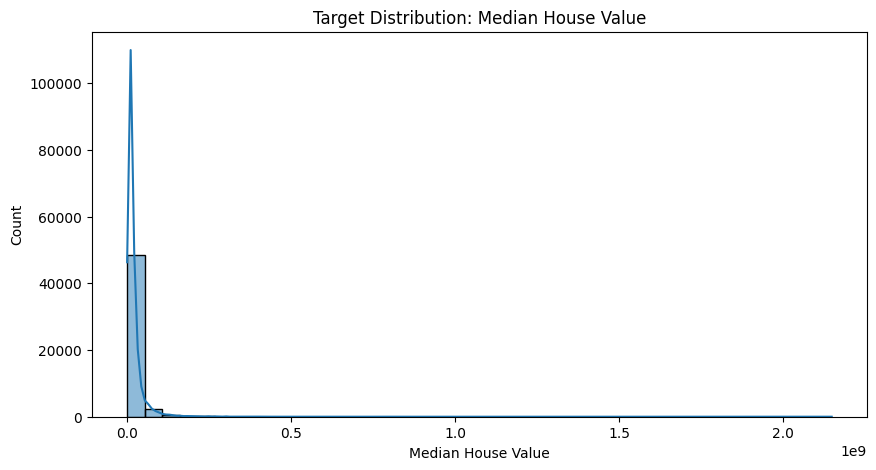

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df_cleaned[target_Col], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

The "peak" of the curve (the mode) is extremely sharp and located near the beginning of the horizontal axis. This tells us that the "affordable" or "mid-range" segment makes up nearly 90-95% of the entire dataset. The market you are analyzing is dominated by a specific price bracket, with luxury properties being statistically rare.

In [ ]:
df_cleaned[target_Col].value_counts()

,count
price,
20000000,564
15000000,535
10000000,533
12500000,529
11000000,522
...,...
12182462,1
7000240,1
7299784,1


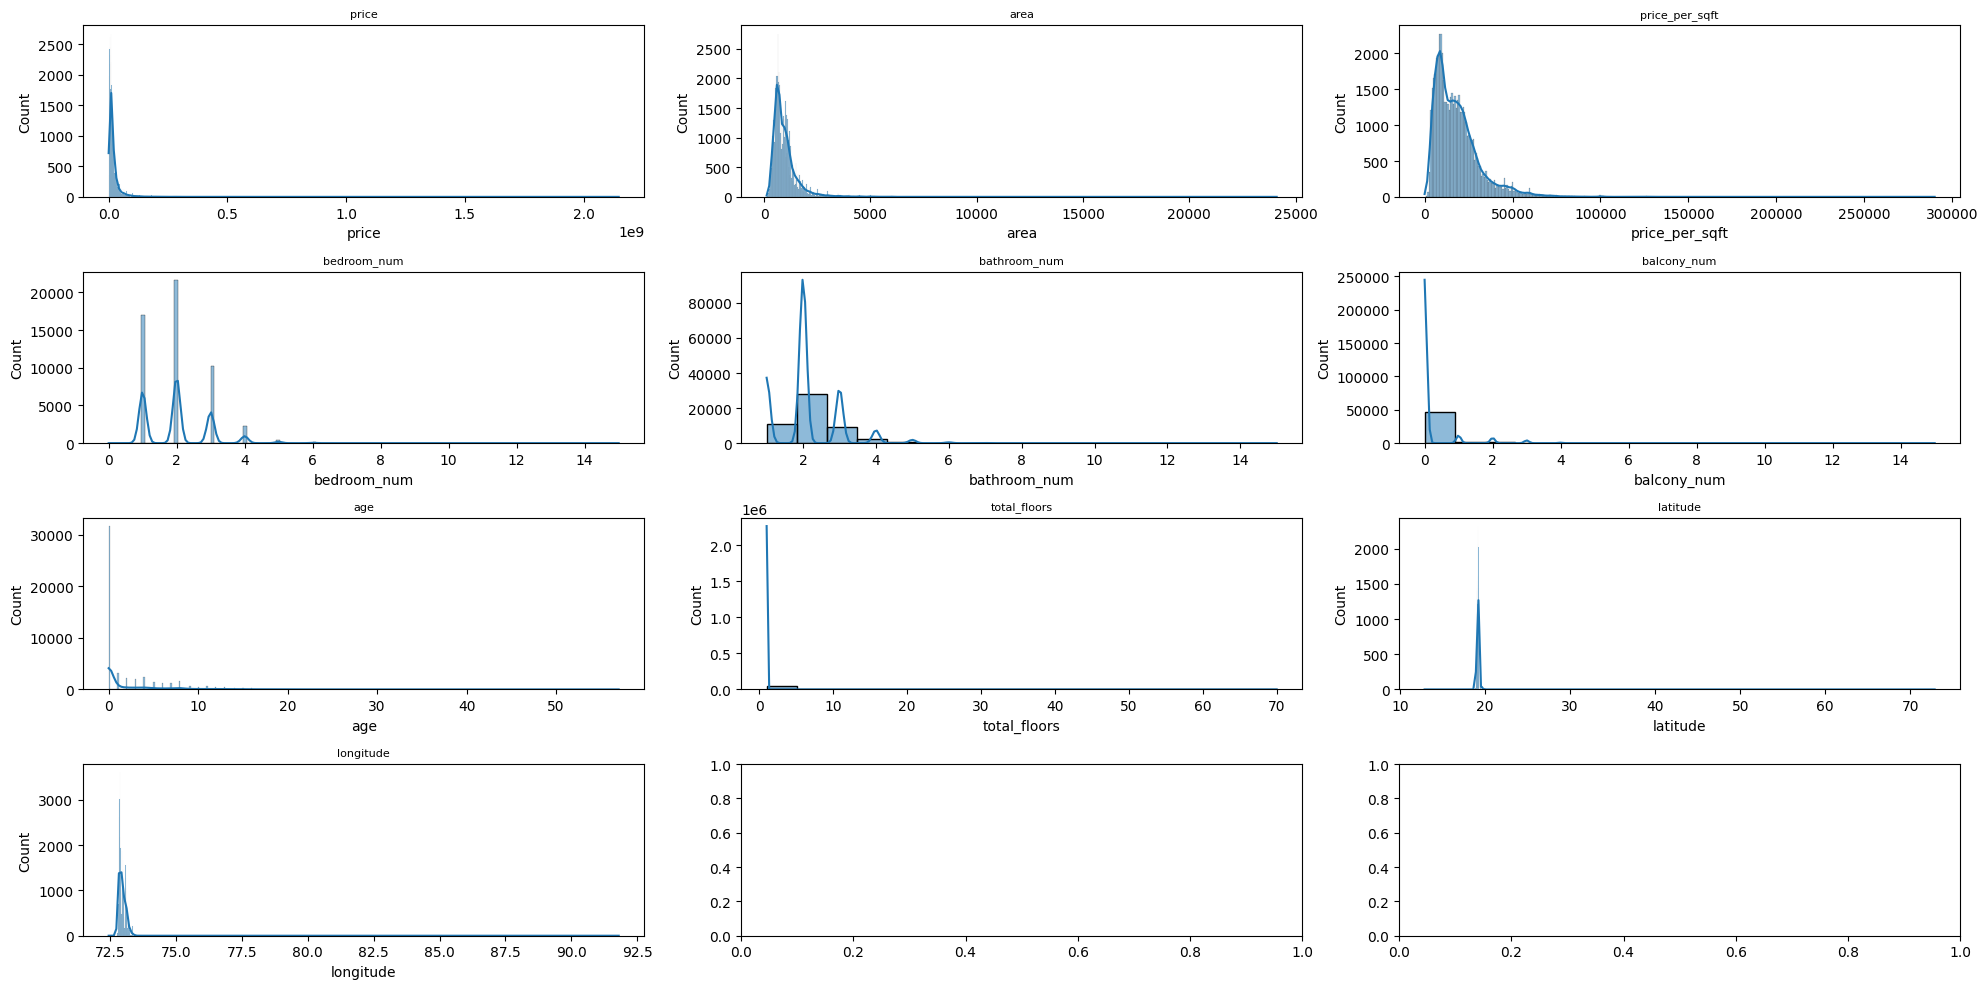

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_cleaned[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

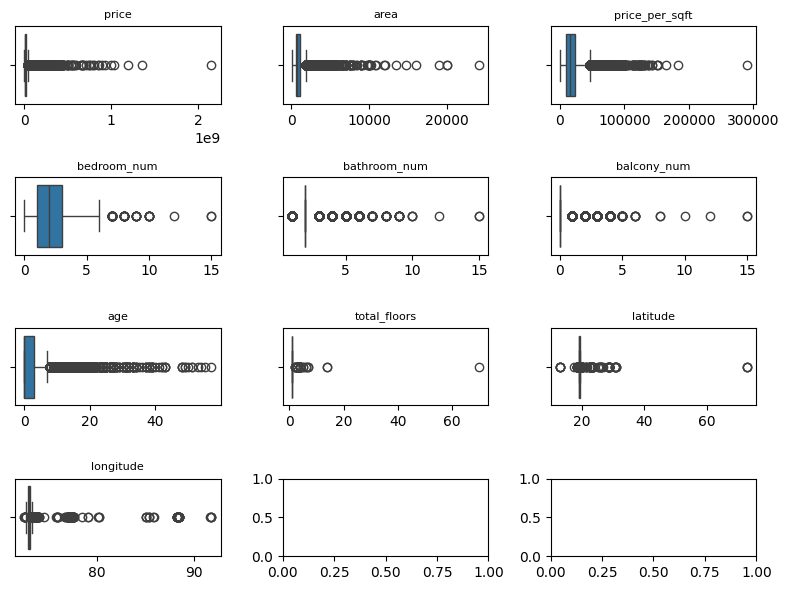

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_cleaned[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
# Correlation with target
corr_with_target = df_cleaned[num_cols].corr()[target_Col].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
price             1.000000
area              0.713582
price_per_sqft    0.681454
bedroom_num       0.553992
bathroom_num      0.546019
balcony_num       0.059256
total_floors      0.048662
age               0.027758
latitude         -0.054623
longitude        -0.079980
Name: price, dtype: float64


In [ ]:
def cap_outliers(df_cleaned, column):
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Capping (Winsorization)
    df_cleaned[column] = np.where(df_cleaned[column] > upper_limit, upper_limit,
                          np.where(df_cleaned[column] < lower_limit, lower_limit, df_cleaned[column]))
    return df_cleaned

In [ ]:
cols_to_cap = ['price', 'area', 'bedroom_num', 'bathroom_num', 'balcony_num', 'age', 'total_floors']

for col in cols_to_cap:
    df_cleaned = cap_outliers(df_cleaned, col)

/tmp/ipykernel_5262/2384107477.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[column] = np.where(df_cleaned[column] > upper_limit, upper_limit,
/tmp/ipykernel_5262/2384107477.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned[column] = np.where(df_cleaned[column] > upper_limit, upper_limit,
/tmp/ipykernel_5262/2384107477.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

In [ ]:
if 'price_per_sqft' in df.columns:
    df.drop(columns=['price_per_sqft'], inplace=True)

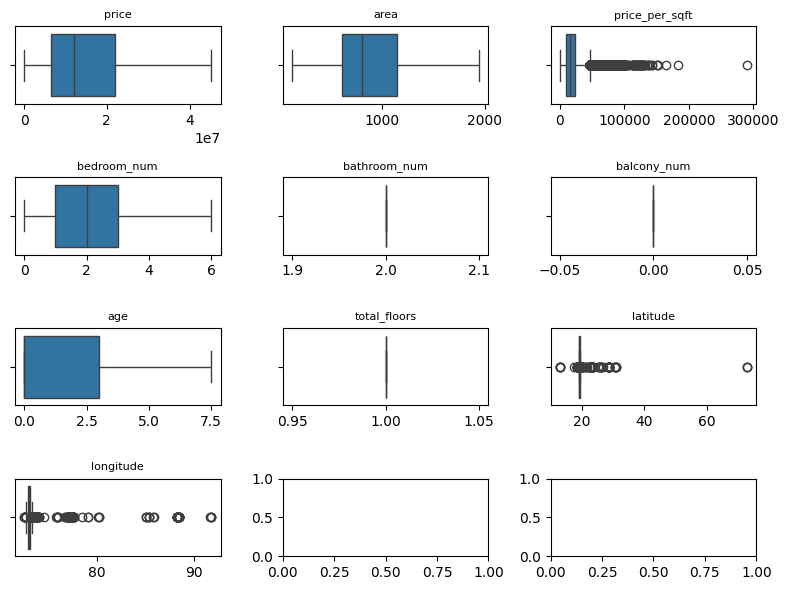

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_cleaned[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

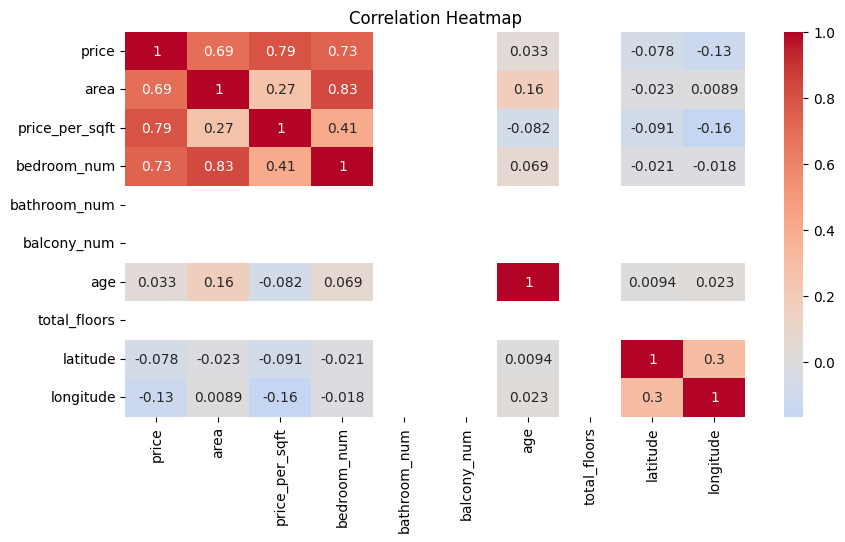

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(
    df_cleaned[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

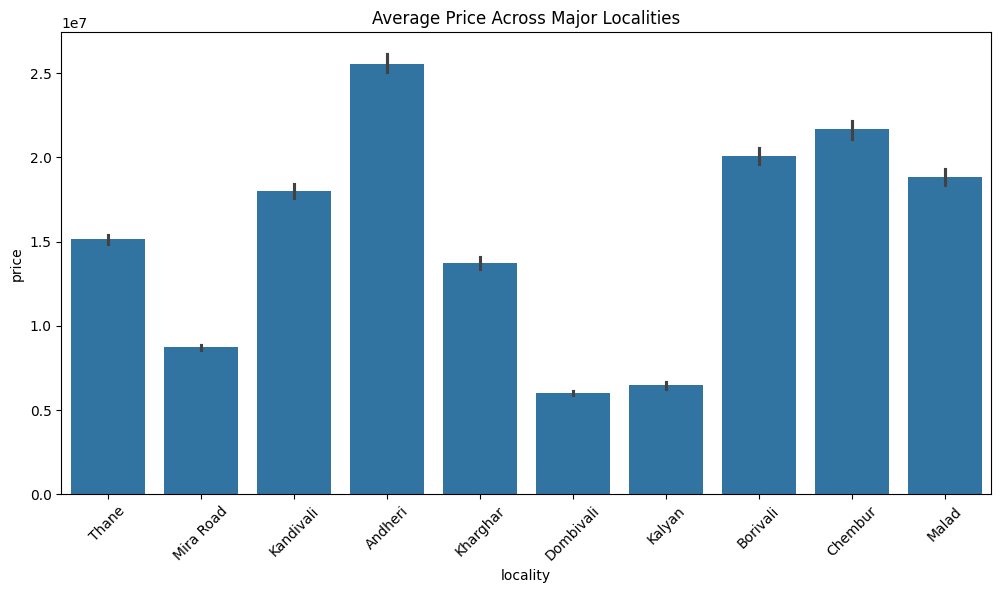

In [ ]:
top_localities = df_cleaned['locality'].value_counts().nlargest(10).index
df_top_loc = df_cleaned[df_cleaned['locality'].isin(top_localities)]
plt.figure(figsize=(12, 6))
sns.barplot(
    data=df_top_loc,
    x='locality',
    y='price',
    order=top_localities  # keeps the order consistent with top 10 frequency
)
plt.xticks(rotation=45)
plt.title("Average Price Across Major Localities")
plt.show()


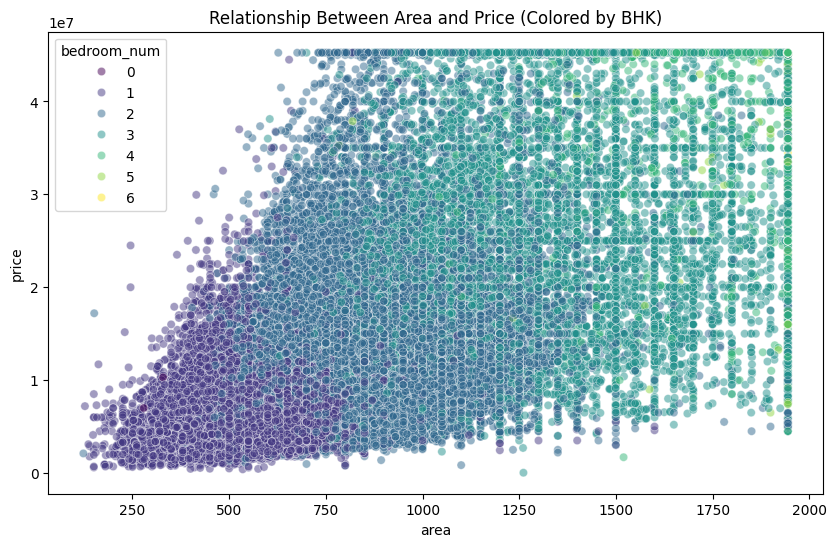

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cleaned, x='area', y='price', hue='bedroom_num', alpha=0.5, palette='viridis')
plt.title("Relationship Between Area and Price (Colored by BHK)")
plt.show()

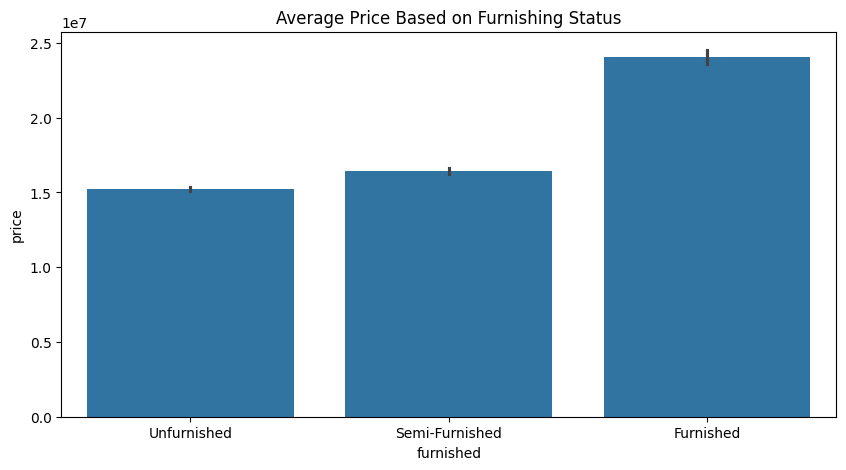

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_cleaned, x='furnished', y='price', estimator=np.mean)
plt.title("Average Price Based on Furnishing Status")
plt.show()

# Insights

- Size is the Strongest Predictor: The Correlation Heatmap shows a strong positive correlation of 0.69 between area and price. This is further proven by the Relationship Between Area and Price scatter plot, which shows a clear upward diagonal trend. As square footage increases, the price consistently rises.

- Locality Defines the "Price Floor": The Average Price Across Major Localities chart reveals massive price gaps. While Andheri leads with the highest average prices (near ₹2.5 Cr), areas like Dombivali and Kalyan are the most budget-friendly (around ₹60–70 Lakhs). This confirms that location is a "multiplier" for price.

- The "BHK" Effect: The heatmap shows a 0.73 correlation between bedroom_num and price. Interestingly, the scatter plot shows that even for the same area, houses with more bedrooms (higher BHK) tend to cluster at higher price points, indicating that "functional space" adds specific value.

- The Luxury Premium (Furnishing): The Average Price Based on Furnishing Status chart shows a significant jump for Furnished homes. There is a clear "convenience premium" where buyers pay substantially more for move-in-ready homes compared to Unfurnished or Semi-Furnished ones.

#Conlusion

- The Mumbai/Thane housing market is primarily driven by a combination of Physical Space (area) and Geographic Prestige (locality).

In [ ]:
df_cleaned.to_csv("cleaned_data.csv",index=False)